In [2]:
import cftime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from scipy import interpolate
from scipy import io
from scipy import ndimage
import xarray as xr
import cmocean 

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
mission_df = pd.read_csv('../../data/mission_df.csv')
mission_df[mission_df['mission number']==32]

,Unnamed: 0,time,mission number,Hs [m] (8marray),Tm [s] (8marray),Mean Dir [deg] (8marray),Mean Dir FRF [deg] (8marray),Mean Dir FRF Math conv (8marray),Mean Wavelength [m] (8marray),wind speed [m/s],wind direction [deg],wind direction FRF [deg],wind direction FRF math convention [deg],water level [m],stokes drift [m/s] (8marray),surf zone width [m],breaking iribarren,surf zone edge [m]
39,39,2021-10-13 17:25:29.998680,32,1.08733,7.631857,58.45004,39.450039,230.549961,61.345759,6.483833,4.238652,-14.761348,284.761348,0.781,0.06732,187.884512,0.2701,262.884512


In [4]:
survey_20211021 = xr.load_dataset('../../data/FRF_geomorphology_DEMs_surveyDEM_20211021.nc')
survey_20211021

<xarray.Dataset> Size: 94kB
Dimensions:                (time: 1, xFRF: 76, yFRF: 51, project: 16)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2021-10-21
  * xFRF                   (xFRF) float64 608B 50.0 62.0 74.0 ... 938.0 950.0
  * yFRF                   (yFRF) float64 408B -100.0 -76.0 ... 1.1e+03
    project                (time, project) object 128B b'D' b'D' ... b'D' b'D'
Data variables:
    elevation              (time, yFRF, xFRF) float64 31kB 2.162 ... -9.155
    latitude               (yFRF, xFRF) float64 31kB 36.18 36.18 ... 36.19 36.19
    longitude              (yFRF, xFRF) float64 31kB -75.75 -75.75 ... -75.74
    surveyNumber           (time) float64 8B 1.228e+03
    surveyVehicle          (time) float32 4B 1.0
    surveyInstrumentation  (time) float32 4B 3.0
    versionDate            (time) datetime64[ns] 8B 2021-10-28
Attributes: (12/46)
    origin:                          USACE/CHL/COAB
    Metadata_Conventions:            Unidata Dataset Discovery v1.0, CF-1.6
    format_version:                  v1.0
    contact_info:                    USACE/CHL/COAB
    geospatial_lat_units:            degrees_north
    cross_shore_angle_description:   cross shore angle at the USACE FRF site ...
    ...                              ...
    geospatial_vertical_positive:    up
    creator_url:                     http://frf.usace.army.mil
    geospatial_vertical_units:       m
    history:                         stuff
    date_created:                    2021-10-28
    date_issued:                     2021-10-28

In [5]:
# There are a lot of dates available here for the whole month of october 10/6-10/23 continuous
# https://chlthredds.erdc.dren.mil/thredds/catalog/frf/geomorphology/elevationTransects/survey/data/catalog.html
bathy_20211008 = nc.Dataset('../../data/FRF_geomorphology_elevationTransects_survey_20211008.nc')

# Get the point cloud data from the transect file
xFRF_survey_points = bathy_20211008['xFRF'][:]
yFRF_survey_points = bathy_20211008['yFRF'][:]
elevation_survey_points = bathy_20211008['elevation'][:]



50.0
950.0
-100.0
1100.0


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_30441/1528477492.py:16: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(bathy_x_grid, bathy_y_grid, elevation_basic,


(50.0, 950.0, -100.0, 1100.0)

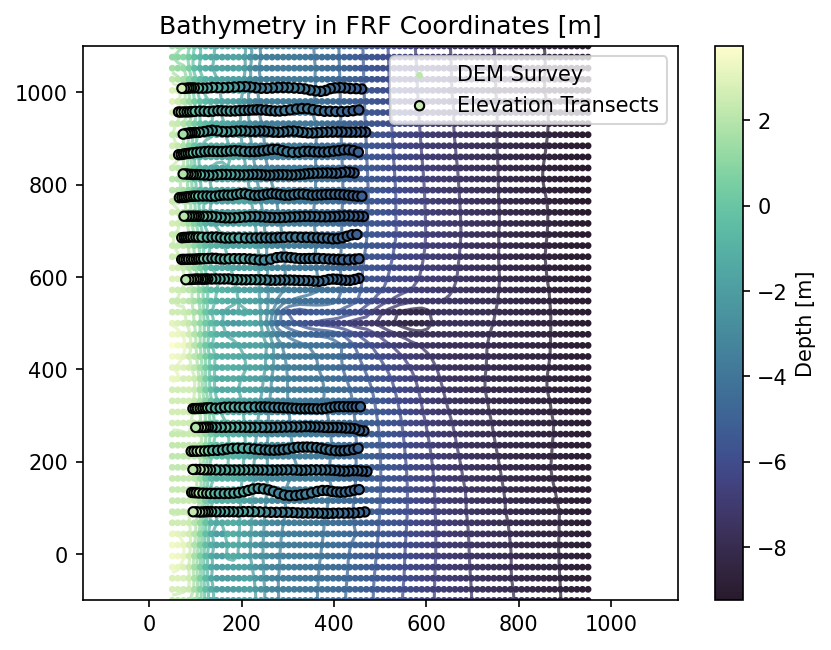

In [6]:
# Load basic processed bathymetry
bathy_basic_data = nc.Dataset('../../data/FRF_geomorphology_DEMs_surveyDEM_20211021.nc')
xFRF = bathy_basic_data['xFRF'][:]
yFRF = bathy_basic_data['yFRF'][:]
bathy_x_grid, bathy_y_grid = np.meshgrid(xFRF, yFRF)
elevation_basic = bathy_basic_data['elevation'][0,:,:]
print(np.min(xFRF))
print(np.max(xFRF))
print(np.min(yFRF))
print(np.max(yFRF))

fig, ax = plt.subplots(dpi=150)
ax.scatter(bathy_x_grid, bathy_y_grid, c=elevation_basic, 
           s=5, vmin=elevation_basic.min(), vmax=elevation_basic.max(),
           cmap=cmocean.cm.deep_r, label='DEM Survey')
ax.contour(bathy_x_grid, bathy_y_grid, elevation_basic, 
           levels=np.linspace(elevation_basic.min(), elevation_basic.max(), 21), 
           cmap=cmocean.cm.deep_r, zorder=-1, alpha=0.75, linewidth=10)
stride = 15
im = ax.scatter(xFRF_survey_points[::stride],
           yFRF_survey_points[::stride],
           s=20, c=elevation_survey_points[::stride],
           edgecolors='k', linewidth=1, vmin=elevation_basic.min(),
           vmax=elevation_basic.max(), cmap=cmocean.cm.deep_r, zorder=5, label='Elevation Transects')
ax.legend()
ax.set_title('Bathymetry in FRF Coordinates [m]')
plt.xlim([0, np.max(xFRF)])
plt.ylim([0, np.max(yFRF)])
plt.colorbar(im, label='Depth [m]')
plt.axis('equal')

901
1001
(2002, 901)
Values to put in SWAN input file 900 1000


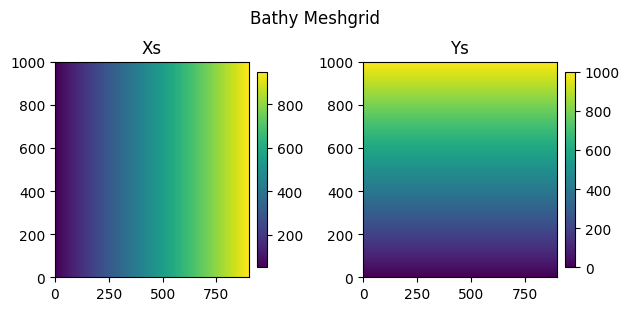

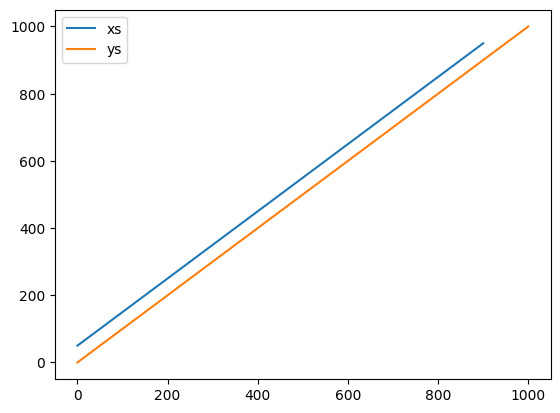

In [116]:
# Define grid cell edge size
x_cgrid_size = 1 # units are meters
y_cgrid_size = 1 # units are meters

# Define grid edges
x_cgrid_min = 50
x_cgrid_max = 950
y_cgrid_min = 0
y_cgrid_max = 1000

# Define number of points based on grid size
num_x_points = int((x_cgrid_max - x_cgrid_min) / x_cgrid_size)+1
print(num_x_points)
num_y_points = int((y_cgrid_max - y_cgrid_min) / y_cgrid_size)+1
print(num_y_points)

# Create mesh grid
x_cgrid, y_cgrid = np.meshgrid(np.linspace(x_cgrid_min, x_cgrid_max, num_x_points),
                               np.linspace(y_cgrid_min, y_cgrid_max, num_y_points))

# Stack the x grid and y grid to be read into swan
swan_cgrid = np.concatenate((x_cgrid, y_cgrid), axis=0)
print(swan_cgrid.shape)

with open('./swan_cgrid.xy', 'w') as file:
    for x in x_cgrid.flatten():
        file.write(f"{x:18.12f}\n")
    for y in y_cgrid.flatten():
        file.write(f"{y:18.12f}\n")

# Save the grid to load in for analysis
io.savemat('./swan_cgrid.mat', {'x_cgrid':x_cgrid, 'y_cgrid':y_cgrid})

print(f'Values to put in SWAN input file {num_x_points-1} {num_y_points-1}')

fig, axs = plt.subplots(1, 2)
xs = axs[0].imshow(x_cgrid, vmin=50, vmax=950, origin='lower')
axs[0].set_title('Xs')
plt.colorbar(xs, ax=axs[0], fraction=0.046, pad=0.04)
ys = axs[1].imshow(y_cgrid, origin='lower')
axs[1].set_title('Ys')
plt.colorbar(ys, ax=axs[1],fraction=0.046, pad=0.04)
fig.suptitle('Bathy Meshgrid', y=0.8)
plt.tight_layout()

plt.figure()
plt.plot(x_cgrid[0, :], label='xs')
plt.plot(y_cgrid[:, 0], label='ys')
plt.legend()

(0.0, 1000.0)

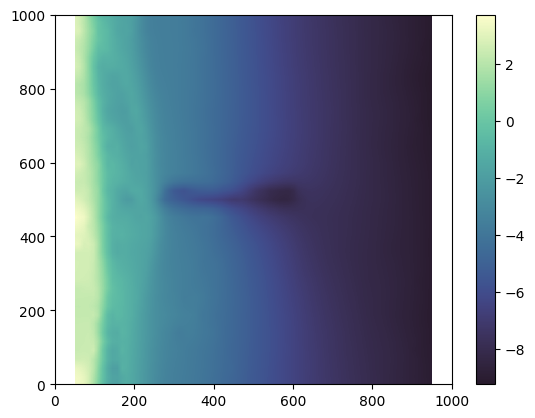

In [121]:
elevation_regridded = interpolate.interpn((xFRF, yFRF), elevation_basic.T, (x_cgrid, y_cgrid), method='linear', fill_value=0)
fig, ax = plt.subplots()
im = ax.pcolormesh(x_cgrid, y_cgrid, elevation_regridded[1:, 1:], shading='flat', cmap=cmocean.cm.deep_r)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])


Text(0.5, 1.0, 'Interpolated Boundary from top')

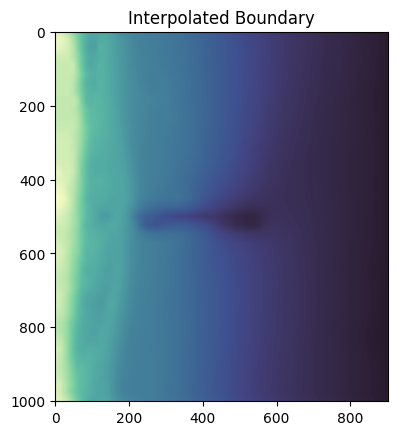

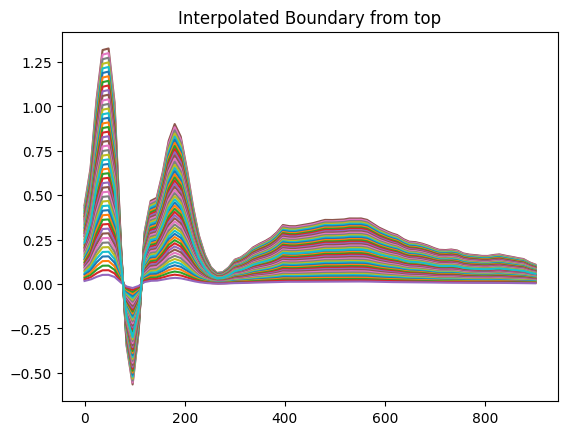

In [127]:
# Create a smooth N-S boundary

elevation_regridded_boundary_interp = elevation_regridded.copy()

n_interp = 51
interp_indices = np.arange(-n_interp//2+1, n_interp//2+1, 1)

# Linear interpolation along cross-shore transects
start_depths = elevation_regridded[interp_indices[-1]]
end_depths =   elevation_regridded[interp_indices[0]]
slope = (end_depths - start_depths) / n_interp

for i, along_shore in enumerate(interp_indices):
    elevation_regridded_boundary_interp[along_shore, :] = end_depths - (i * slope)

plt.imshow(elevation_regridded_boundary_interp,  cmap=cmocean.cm.deep_r)
plt.title('Interpolated Boundary')

plt.figure()
plt.plot(start_depths[:, np.newaxis] - elevation_regridded_boundary_interp[:25, :].T)
plt.plot(start_depths[:, np.newaxis] - elevation_regridded_boundary_interp[-25:, :].T);
plt.title('Interpolated Boundary from top')


navd88_water_level=0.781


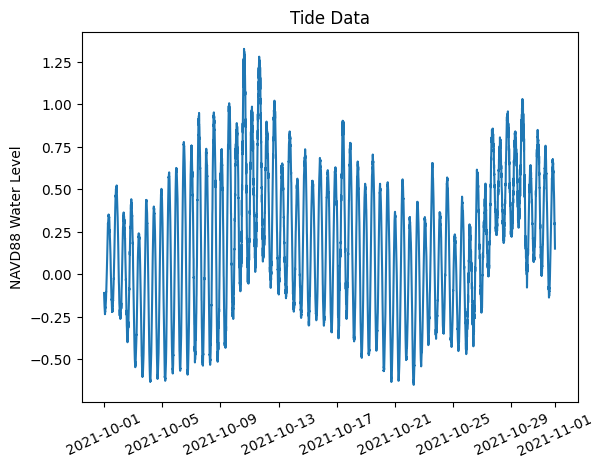

In [133]:
tides = xr.load_dataset('../../data/FRF-ocean_waterlevel_eopNoaaTide_202110.nc')
water_level = tides.waterLevel # relative NAVD88 just like bathymetry
plt.plot(water_level.time, water_level)
plt.xticks(rotation=25)
plt.ylabel('NAVD88 Water Level')
plt.title('Tide Data')
mission_id = 32
mission = xr.load_dataset(f'../../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission_id}.nc')
navd88_water_level = water_level.sel(time=mission.time.mean(), method='nearest').item()
print(f'{navd88_water_level=}')


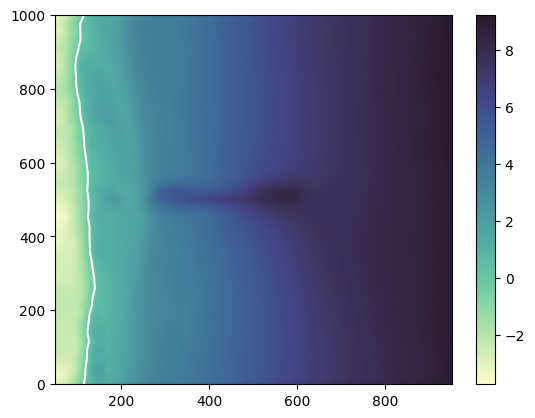

In [130]:
water_depth_nadv88 = -elevation_regridded_boundary_interp # From bathymetry elevation (land is positive) to depths  

assert(~np.any(np.isnan(water_depth_nadv88)))

plt.pcolormesh(x_cgrid, y_cgrid, water_depth_nadv88, cmap=cmocean.cm.deep)
plt.colorbar()
plt.contour(x_cgrid, y_cgrid, water_depth_nadv88, levels=[0], colors='white')


In [44]:
# Interpolate between top and bottom boundary? 
mean_boundary_profile = (elevation_regridded[0,:] + elevation_regridded[-1,:]) / 2
bottom_along_shore_locs = np.arange(-n_interp//2, n_interp//2, 1)



interp_range = 50
bottom_along_shore_locs = y_cgrid[:interp_range,0]
for n in range(900):
    swandepth[:interp_range, n] = np.interp(bottom_along_shore_locs, [y_cgrid[0,0], y_cgrid[interp_range-1,0]], 
                                     [mean_swandepth[n], swandepth[0,n]])
    
# Expand the bathymetry South of the last profile 
top_along_shore_locs = y_cgrid[-interp_range:,0]
for n in range(900):
    swandepth[-interp_range:, n] = np.interp(top_along_shore_locs, [y_cgrid[-interp_range+1,0], y_cgrid[-1,0]], 
                                     [swandepth[-1,n], mean_swandepth[n]])
plt.pcolormesh(x_cgrid, y_cgrid, swandepth)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title(f'Interpolated Periodic Boundary {interp_range*2} cells')
plt.colorbar()
plt.axhline(interp_range, c='r', linestyle=':')
plt.axhline(len(y_cgrid)-interp_range, c='r', linestyle=':')
plt.figure()
for i in range(interp_range):
    plt.plot(swandepth[i]  - mean_swandepth, c='r', alpha=i/interp_range, label=i)
    plt.plot(swandepth[-i] - mean_swandepth, c='b', alpha=i/interp_range, label=i)

NameError: name 'mean_swandepth' is not defined

In [ ]:
# Other stuff

Text(0.5, 1.0, 'Linearly Interpolated Survey Data')

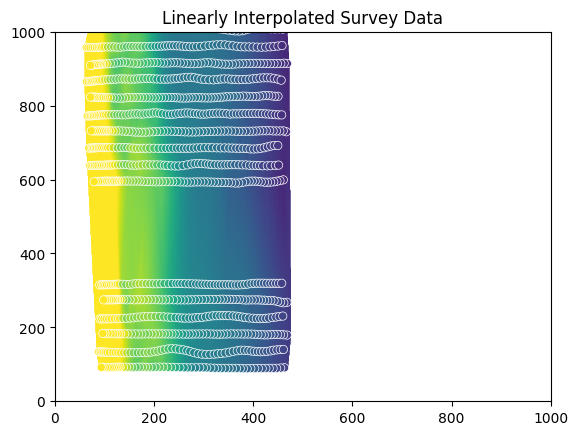

In [33]:
zgrid = interpolate.griddata((xFRF_survey_points, yFRF_survey_points), elevation_survey_points,
                             (x_cgrid, y_cgrid), method='linear', fill_value=np.nan)
vmin = -6
vmax = 0
plt.scatter(x_cgrid, y_cgrid, c=zgrid, vmin=vmin, vmax=vmax, s=1)
plt.scatter(xFRF_survey_points[::10],
            yFRF_survey_points[::10],
            c=elevation_survey_points[::10], edgecolors='w', linewidth=0.5, vmin=vmin, vmax=vmax)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title('Linearly Interpolated Survey Data')

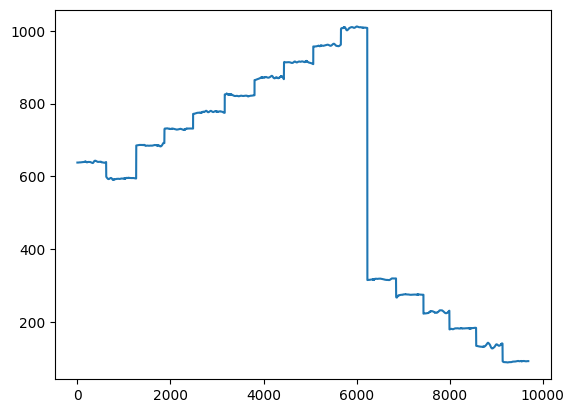

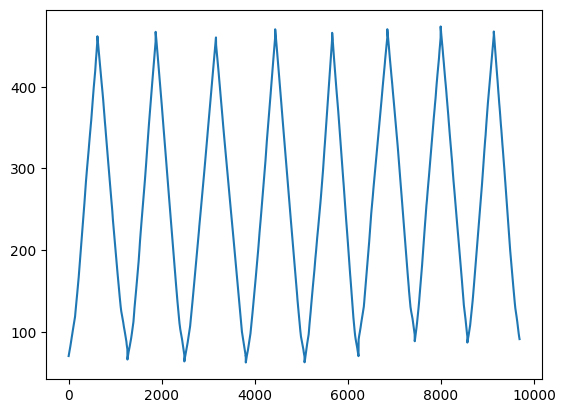

In [10]:
plt.plot(yFRF_survey_points)
# plt.ylim([300, 600])
plt.figure()
plt.plot(xFRF_survey_points)

In [35]:
# Fill missing X data (offshore)
# elevation_regridded = ndimage.gaussian_filter(elevation_regridded, sigma=10)
zgrid[0:100,:] = elevation_regridded[0:100,:]
zgrid[300:600,:] = elevation_regridded[300:600,:]

# # Fill missing Y data
zgrid[:,400:] = elevation_regridded[:,400:]
zgrid[:,:65] = elevation_regridded[:,:65]


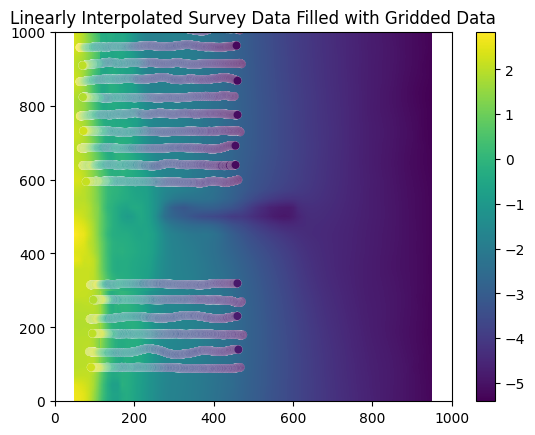

In [36]:
plt.pcolormesh(x_cgrid, y_cgrid, zgrid)
plt.scatter(xFRF_survey_points, yFRF_survey_points, c=elevation_survey_points, edgecolors='w', linewidth=0.1)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title('Linearly Interpolated Survey Data Filled with Gridded Data')
plt.colorbar()

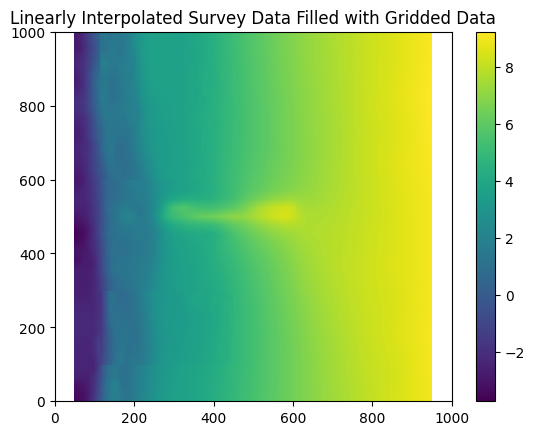

In [13]:
swandepth = -zgrid
swandepth = np.nan_to_num(swandepth, copy=False)
plt.pcolormesh(x_cgrid, y_cgrid, swandepth)
# plt.scatter(xFRF_survey_points, yFRF_survey_points, c=elevation_survey_points, edgecolors='w', linewidth=0.1)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title('Linearly Interpolated Survey Data Filled with Gridded Data')
plt.colorbar()

# Note there's some weirdness around the boundaries


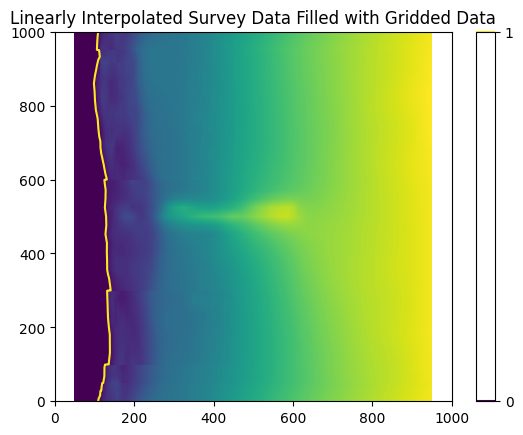

In [37]:
# Note(@mleclair) Close enough for now, this is still a little janky around the edges, maybe we could interpolate profiles in the alongshore instead of blurring
swandepth[swandepth < 0.1 ] = 0.0 # TODO(@mleclair): Is this necessary?
plt.pcolormesh(x_cgrid, y_cgrid, swandepth)
plt.contour(x_cgrid, y_cgrid, swandepth, levels=[0, 1])
# plt.scatter(xFRF_survey_points, yFRF_survey_points, c=elevation_survey_points, edgecolors='w', linewidth=0.1)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title('Linearly Interpolated Survey Data Filled with Gridded Data')
plt.colorbar()

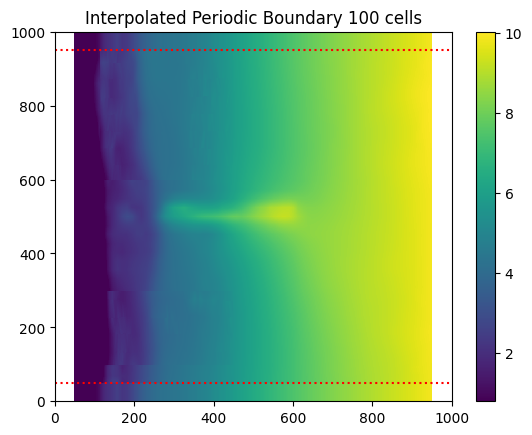

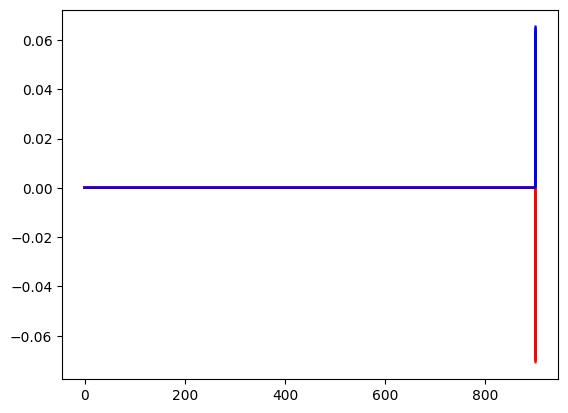

In [38]:
mean_swandepth = mean_swandepth = (swandepth[0,:] + swandepth[-1,:]) / 2
interp_range = 50
bottom_along_shore_locs = y_cgrid[:interp_range,0]
for n in range(900):
    swandepth[:interp_range, n] = np.interp(bottom_along_shore_locs, [y_cgrid[0,0], y_cgrid[interp_range-1,0]], 
                                     [mean_swandepth[n], swandepth[0,n]])
    
# Expand the bathymetry South of the last profile 
top_along_shore_locs = y_cgrid[-interp_range:,0]
for n in range(900):
    swandepth[-interp_range:, n] = np.interp(top_along_shore_locs, [y_cgrid[-interp_range+1,0], y_cgrid[-1,0]], 
                                     [swandepth[-1,n], mean_swandepth[n]])
plt.pcolormesh(x_cgrid, y_cgrid, swandepth)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title(f'Interpolated Periodic Boundary {interp_range*2} cells')
plt.colorbar()
plt.axhline(interp_range, c='r', linestyle=':')
plt.axhline(len(y_cgrid)-interp_range, c='r', linestyle=':')
plt.figure()
for i in range(interp_range):
    plt.plot(swandepth[i]  - mean_swandepth, c='r', alpha=i/interp_range, label=i)
    plt.plot(swandepth[-i] - mean_swandepth, c='b', alpha=i/interp_range, label=i)

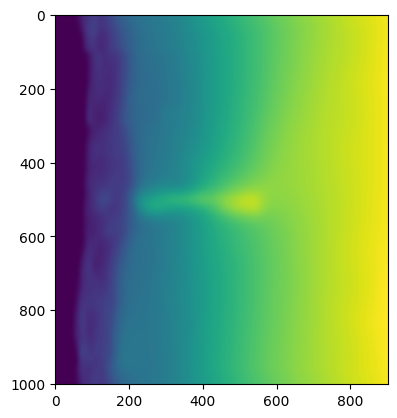

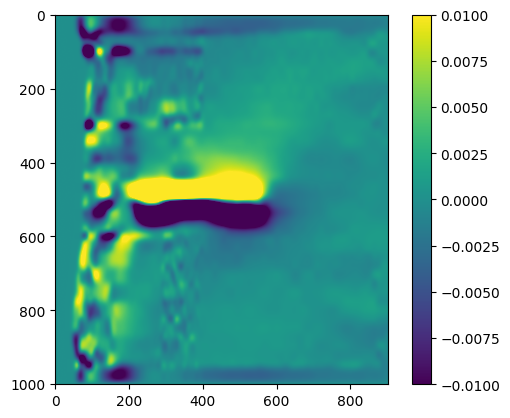

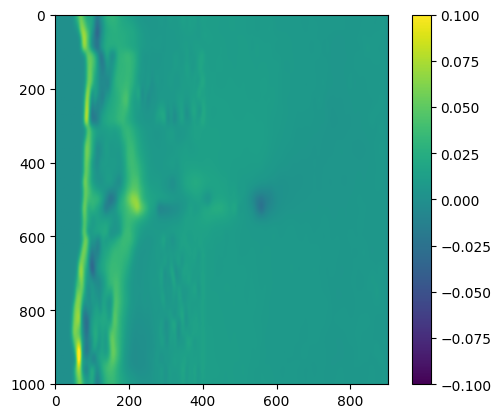

In [16]:
sd = ndimage.gaussian_filter(swandepth, sigma=(10, 5)) # TODO(@mleclair): Is this necessary?
plt.imshow(sd)
plt.figure()
dx, dy = np.gradient(sd)
plt.imshow(dx, vmin=-0.01, vmax=0.01)
plt.colorbar()
plt.figure()
plt.imshow(dy, vmin=-0.1, vmax=0.1)
plt.colorbar()

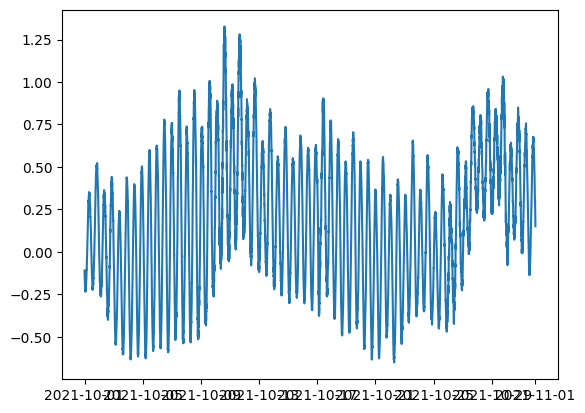

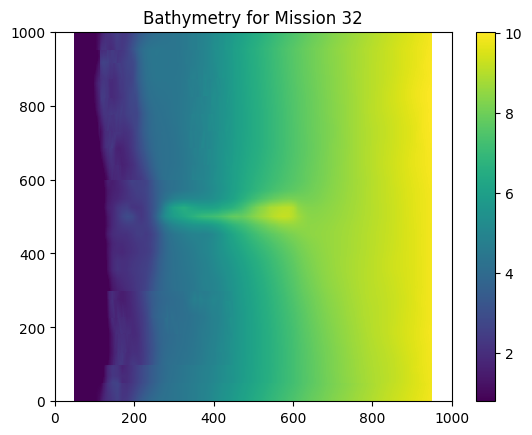

In [17]:
tides = xr.load_dataset('../../data/FRF-ocean_waterlevel_eopNoaaTide_202110.nc')
water_level = tides.waterLevel # relative NAVD88 just like bathymetry
plt.plot(water_level.time, water_level)
mission_id = 32
mission = xr.load_dataset(f'../../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission_id}.nc')
# plt.axvline(mission.time.min().dt)
# plt.axvline(mission.time.max().dt)
navd88_water_level = water_level.sel(time=mission.time.mean(), method='nearest').item()
navd88_water_level
swandepth += navd88_water_level

plt.figure()
plt.pcolormesh(x_cgrid, y_cgrid, swandepth)
# plt.scatter(xFRF_survey_points, yFRF_survey_points, c=elevation_survey_points, edgecolors='w', linewidth=0.1)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title(f'Bathymetry for Mission {mission_id}')
plt.colorbar()

In [20]:
df = pd.read_csv('../../data/mission_df.csv')
navd88_water_level = df[df['mission number']==32]['water level [m]'].item()
navd88_water_level

0.781

In [29]:
df[df['mission number']==32]['water level [m]']

39    0.781
Name: water level [m], dtype: float64

In [21]:
grd = xr.load_dataset('ocean_dunex_base_grd.nc')
grd_old = grd.copy()
# grd['h'] = grd['h'] - 0.399 + navd88_water_level
# grd['hraw'] = grd['hraw'] + 0.399 + navd88_water_level
grd['h'].values = sd + navd88_water_level
grd['hraw'].values = sd[np.newaxis, :] + navd88_water_level
grd.to_netcdf('ocean_dunex_grd32.nc')
# from roms2swan import roms2swan
# roms2swan(grd)

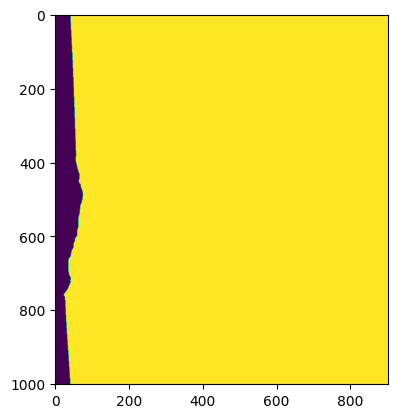

In [33]:
plt.imshow(grd_old['h'] - 1 > 0)

In [33]:
grd['h'].values.shape

(1001, 901)

In [1]:
grd = xr.load_dataset('ocean_dunex_base_grd.nc')

tides = xr.load_dataset('../../data/FRF-ocean_waterlevel_eopNoaaTide_202110.nc')
water_level = tides.waterLevel # relative NAVD88 just like bathymetry
plt.plot(water_level.time, water_level)
mission_id = 32
mission = xr.load_dataset(f'../../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission_id}.nc')
navd88_water_level = water_level.sel(time=mission.time.mean(), method='nearest').item()


grd['h'] = grd['h'] + navd88_water_level
grd['hraw'] = grd['hraw'] + navd88_water_level
grd['h'].values[grd['h'] < 0.1 ] = 0.0 # TODO(@mleclair): Is this necessary?
grd['hraw'].values[grd['hraw'] < 0.1 ] = 0.0 # TODO(@mleclair): Is this necessary?

plt.figure()
plt.pcolormesh(grd['xi_rho'], grd['eta_rho'], grd['h'])
plt.contour(grd['xi_rho'], grd['eta_rho'], grd['h'], levels=[-2, -1, 0, 1, 2], cmap='hot')
# plt.scatter(xFRF_survey_points, yFRF_survey_points, c=elevation_survey_points, edgecolors='w', linewidth=0.1)
fig.colorbar(im)
plt.xlim([0, 1000])
plt.ylim([0, 1000])
plt.title(f'Bathymetry for Mission {mission_id}')
plt.colorbar()

grd.to_netcdf(f'ocean_dunex_{mission_id}.nc')

NameError: name 'xr' is not defined

In [35]:
## Figure out how to generate the nc & grd files we actually need

In [36]:
from create_roms_netcdf_grid_file import create_roms_netcdf_grid_file

fname ='roms.nc'
create_roms_netcdf_grid_file('roms.nc', swandepth.shape[0]+1, swandepth.shape[1]+1)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (create_roms_netcdf_grid_file.py, line 52)

In [37]:
rms = xr.load_dataset('roms.nc')
rms.h

<xarray.DataArray 'h' (xi_rho: 1001, eta_rho: 901)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * xi_rho   (xi_rho) int64 8kB 0 1 2 3 4 5 6 7 ... 994 995 996 997 998 999 1000
  * eta_rho  (eta_rho) int64 7kB 0 1 2 3 4 5 6 7 ... 894 895 896 897 898 899 900
Attributes:
    long_name:  Final bathymetry at RHO-points
    units:      meter
    field:      bath, scalar

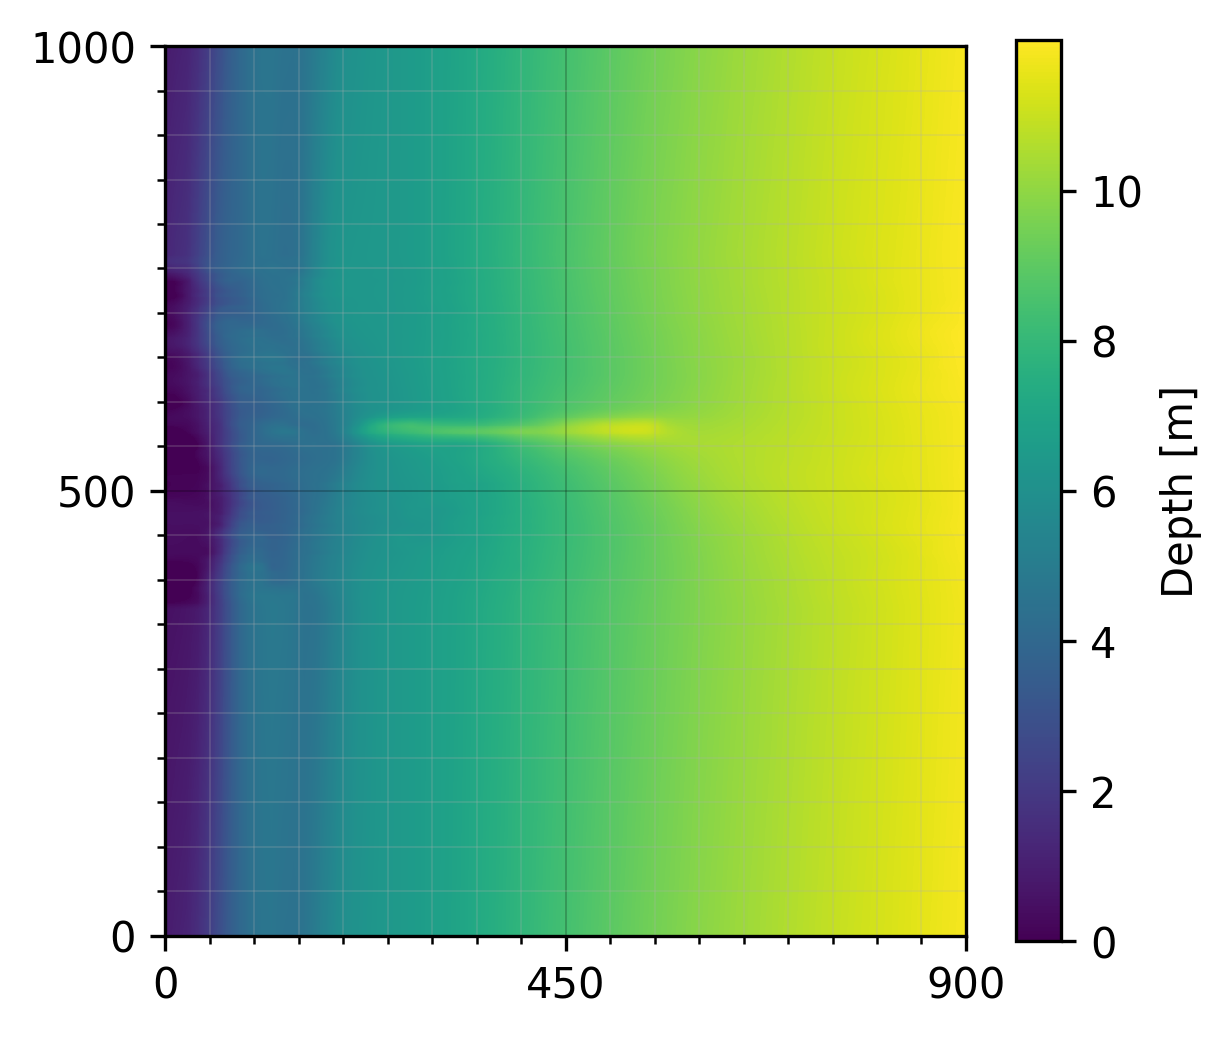

In [38]:
import matplotlib.ticker as plticker

my_dpi=300
fig=plt.figure(figsize=(float(grd.h.shape[0])/my_dpi,float(grd.h.shape[1])/my_dpi),dpi=my_dpi)
ax=fig.add_subplot(111)
plt.pcolormesh(grd['xi_rho'], grd['eta_rho'], grd['h'])
# plt.axis('equal')
fig.subplots_adjust(left=0,right=1,bottom=0,top=1)
myInterval=100.
loc = plticker.MultipleLocator(base=myInterval)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
myInterval=50.
loc = plticker.MultipleLocator(base=myInterval)
ax.xaxis.set_minor_locator(loc)
ax.yaxis.set_minor_locator(loc)
ax.grid(which='major', axis='both', linestyle='-', c='k', linewidth=0.1)
ax.grid(which='minor', axis='both', linestyle='-', linewidth=0.1)
ax.set_xlim([0, 900])
ax.set_ylim([0, 1000])
ax.set_aspect(1)
ax.set_xticks([0, 450, 900])
ax.set_yticks([0, 500, 1000])
plt.colorbar(label='Depth [m]')
# plt.axes('off')

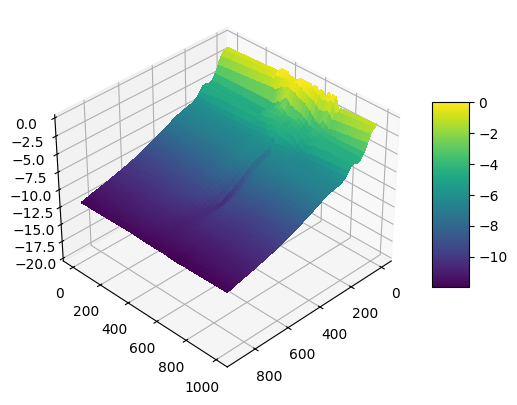

In [39]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data.
# Plot the surface.
surf = ax.plot_surface(*np.meshgrid(grd['xi_rho'], grd['eta_rho']), -grd['h'], cmap=cm.viridis,
                       linewidth=0, antialiased=False)
ax.view_init(elev=35, azim=45, roll=0)
ax.set_zlim([-20, 0])
# Customize the z axis.
# ax.set_zlim(-1.01, 1.01)
# ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
# ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()


<Figure size 640x480 with 0 Axes>

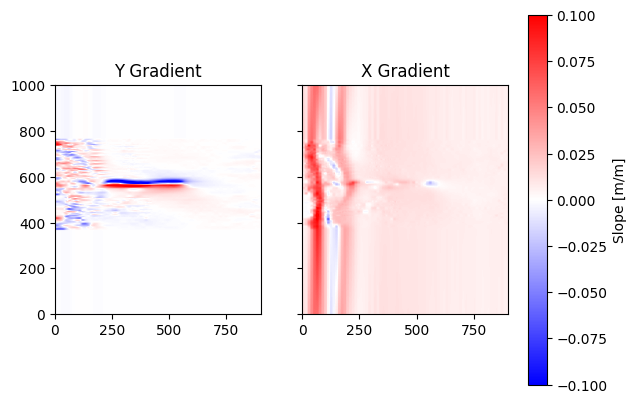

<Figure size 640x480 with 0 Axes>

In [47]:
from scipy import ndimage
# h = ndimage.gaussian_filter(grd.h, sigma=(5, 1))
# plt.imshow(h)
# plt.colorbar()
# plt.figure()
# plt.imshow(h-grd.h)
# plt.figure()
grd = xr.load_dataset('./ocean_dunex_grd.nc')
dx, dy = np.gradient(grd.h)
fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].imshow(dx, vmin=-0.1, vmax=0.1, origin='lower', cmap='bwr')
cb = axs[1].imshow(dy, vmin=-0.1, vmax=0.1, origin='lower', cmap='bwr')
plt.colorbar(cb, ax=axs, fraction=0.046, pad=0.04, label='Slope [m/m]')
axs[0].set_title('Y Gradient')
axs[1].set_title('X Gradient')

plt.figure()

# dx, dy = np.gradient(h)
# plt.imshow(dx, vmin=-0.1, vmax=0.1)
# plt.colorbar()
# plt.figure()
# plt.imshow(dy, vmin=-0.1, vmax=0.1)
# plt.colorbar()


In [7]:
grd = xr.load_dataset('./ocean_dunex_grd.nc')
grd

<xarray.Dataset> Size: 202MB
Dimensions:    (one: 1, bath: 1, eta_rho: 1001, xi_rho: 901, eta_psi: 1000,
                xi_psi: 900, eta_u: 1001, xi_u: 900, eta_v: 1000, xi_v: 901)
Dimensions without coordinates: one, bath, eta_rho, xi_rho, eta_psi, xi_psi,
                                eta_u, xi_u, eta_v, xi_v
Data variables: (12/34)
    xl         (one) float64 8B 900.0
    el         (one) float64 8B 3e+03
    JPRJ       |S2 2B b'ME'
    spherical  (one) |S1 1B b'F'
    depthmin   (one) int16 2B -3
    depthmax   (one) int16 2B 9
    ...         ...
    lon_v      (eta_v, xi_v) float64 7MB 0.0004497 0.0004587 ... 0.008544
    mask_rho   (eta_rho, xi_rho) float64 7MB 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    mask_u     (eta_u, xi_u) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    mask_v     (eta_v, xi_v) float64 7MB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    mask_psi   (eta_psi, xi_psi) float64 7MB 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0
    angle      (eta_rho, xi_rho) float64 7MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    type:     ROMS GRID file
    gridid:   theGridTitle
    history:  Created by create_roms_netcdf_grid_file, on 16-Nov-2023 15:50:43
    title:    ROMS Application

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_30441/2881392317.py:1: RuntimeWarning: invalid value encountered in sqrt
  plt.pcolormesh(np.sqrt(9.8 * grd.h.values), shading='auto')


(0.0, 901.0, 0.0, 1001.0)

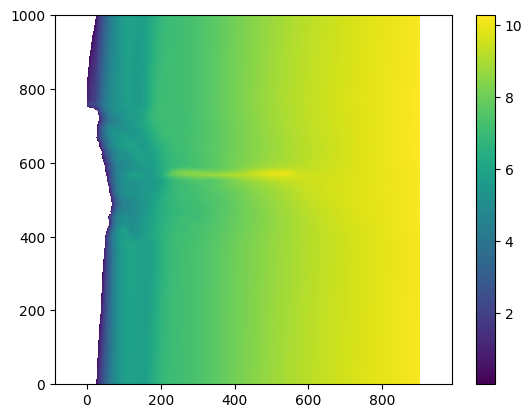

: 

In [24]:
plt.pcolormesh(np.sqrt(9.8 * grd.h.values), shading='auto')
plt.colorbar()
plt.axis('equal')